ISI distance: 0.71835315


/home/docker/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


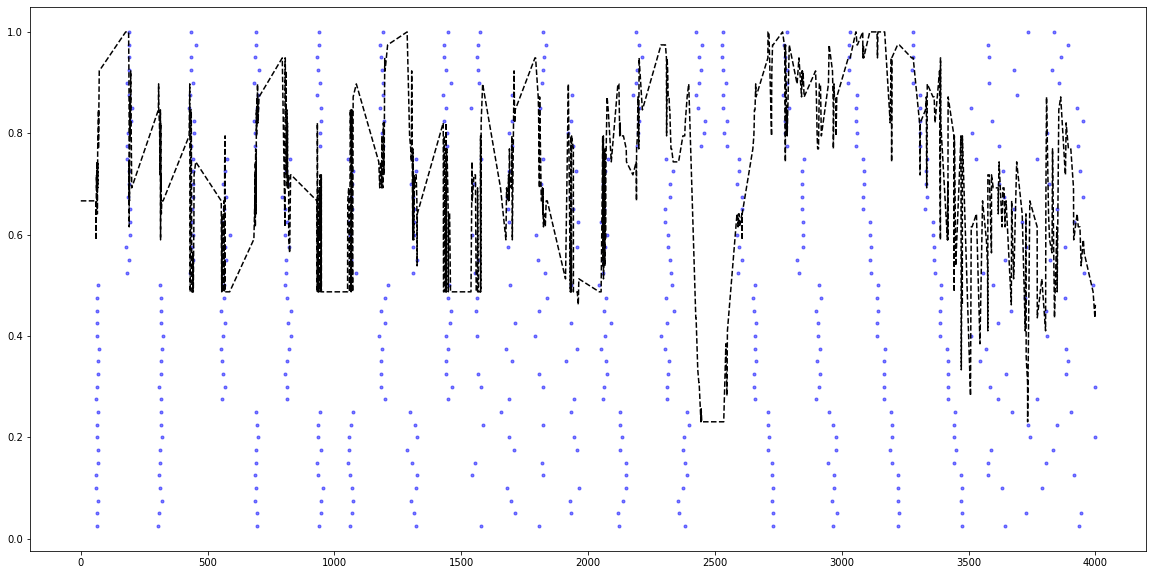

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyspike as spk
import os

data_path = os.path.expanduser("~/packages/PySpike/test/PySpike_testdata.txt")
spike_trains = spk.load_spike_trains_from_txt(data_path, edges=(0, 4000))

n_spike_trains = len(spike_trains)
y_max = n_spike_trains
plt.figure(figsize=(20, 10))
for iS, spike_train in enumerate(spike_trains):
    plt.plot(np.array(spike_train), [(iS +1.0)/n_spike_trains] * len(spike_train), "b.", alpha=0.5)
isi_profile = spk.spike_sync_profile(spike_trains)
x, y = isi_profile.get_plottable_data()
plt.plot(x, y, 'k--')
print("ISI distance: %.8f" % isi_profile.avrg())
plt.show()

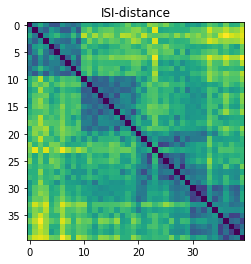

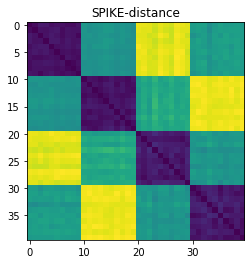

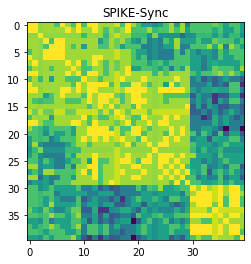

In [2]:
spike_trains = spk.load_spike_trains_from_txt(data_path, 4000)

plt.figure()
isi_distance = spk.isi_distance_matrix(spike_trains)
plt.imshow(isi_distance, interpolation='none')
plt.title("ISI-distance")

plt.figure()
spike_distance = spk.spike_distance_matrix(spike_trains, interval=(0,1000))
plt.imshow(spike_distance, interpolation='none')
plt.title("SPIKE-distance")

plt.figure()
spike_sync = spk.spike_sync_matrix(spike_trains, interval=(2000,4000))
plt.imshow(spike_sync, interpolation='none')
plt.title("SPIKE-Sync")

plt.show()
